Prepare the environment
-----------------------

First we'll import various functions that we'll need for generating the report.

In [1]:
%matplotlib inline

from os import environ
from os.path import join, exists, expandvars
import pandas as pd
from skbio.draw import boxplots

from taxcompare.eval_framework import (get_expected_tables_lookup, 
                                       find_and_process_result_tables,
                                       compute_mock_results,
                                       compute_mantel,
                                       generate_pr_scatter_plots,
                                       boxplot_from_data_frame,
                                       heatmap_from_data_frame,
                                       method_by_dataset_a1,
                                       method_by_dataset_a2,
                                       performance_rank_comparisons,
                                       parameter_comparisons,
                                       method_by_dataset_iterations)

Configure local environment-specific values
-------------------------------------------

**This is the only cell that you will need to edit to generate reports locally.** After editing this cell, you can run all cells in this notebook to generate your analysis report. Some of the analyses make take a few minutes to run, and analyses at more specific taxonomic levels (e.g., genus or species) will be slower than analyses at more general taxonomic levels (e.g., phylum, class). 

**This cell will not run until you fill in a taxonomic level (``2`` through ``7``).**

In [2]:
## INDICATE THE PARAMETER IDS FOR YOUR METHOD AS A COMMA-SEPARATED LIST

new_param_ids = {'mothur':['confidence']}

In [3]:
## project_dir should be the directory where you've downloaded (or cloned) the 
## short-read-tax-assignment repository. 
project_dir = expandvars("$HOME/data/short-read-tax-assignment")

precomputed_results_dir = expandvars("$HOME/data/short-read-tax-assignment/data/precomputed-results/")
expected_results_dir = join(precomputed_results_dir, "simulated-community")

## results_dirs should contain the directory or directories where
## results can be found. By default, this is just the precomputed 
## results included with the project. If other results should be included, 
## absolute paths to those directories should be added to this list.
results_dirs = \
 [precomputed_results_dir,
  ]

## Taxonomic level at which analyses should be performed. Edit this to
## the desired taxonomic level. 
# 2: phylum, 3: class, 4: order, 5: family, 6: genus, 7: species
taxonomic_level = int(environ['taxonomic_level'])

## Reference choice (must be partial-ref or full-ref)
reference_choice = environ['reference_choice']

## Minimum number of times an OTU must be observed for it to be included in analyses. Edit this
## to analyze the effect of the minimum count on taxonomic results.
min_count = 1

# set to true if select tables should be written as Excel files (useful for publication)
write_xls_files = False

In [4]:
# Define the subdirectories where the data should be, and confirm that they exist.
simulated_results_dirs = [join(results_dir,"simulated-community") for results_dir in results_dirs]

for simulated_results_dir in simulated_results_dirs:
    assert exists(simulated_results_dir), "Simulated community result directory doesn't exist: %s" % simulated_results_dir

Find pre-computed tables, expected tables, and "query" tables
-------------------------------------------------------------

Next we'll use the paths defined above to find all of the tables that will be compared. These include the *pre-computed result* tables (i.e., the ones that the new methods will be compared to), the *expected result* tables (i.e., the tables containing the known composition of the mock microbial communities), and the *query result* tables (i.e., the tables generated with the new method(s) that we want to compare to the *pre-computed result* tables).

In [5]:
results = []
for simulated_results_dir in simulated_results_dirs:
    results += find_and_process_result_tables(simulated_results_dir)

In [6]:
# Uncomment for test runs (looks at a small subset of the data)

# from random import shuffle
# shuffle(results)
# results = results[:10]

In [7]:
## SPECIFY A NEW NAME FOR YOUR SUMMARY FILE

result_fp = join(precomputed_results_dir,'simulated-community', 'level%d-results-w-mothur.csv') % taxonomic_level

In [8]:

if exists(result_fp):
    simulated_results = pd.DataFrame.from_csv(result_fp)
else:
    expected_tables = get_expected_tables_lookup(expected_results_dir, level=taxonomic_level)
    simulated_results = compute_mock_results(results, expected_tables, taxonomy_level=taxonomic_level, min_count=min_count)
    simulated_results.to_csv()

In [9]:
refernece_choice_v = [e.endswith(reference_choice) for e in simulated_results['Parameters']]
simulated_results = simulated_results[refernece_choice_v]

Evalution 1: Compute and summarize precision, recall, and F-measure
-------------------------------------------------------------------

In this evaluation, we compute and summarize precision, recall, and F-measure of each result (pre-computed and query) based on the known composition of the simulated communities. We then summarize the results in two ways: first with boxplots, and second with a table of the top methods based on their F-measures.

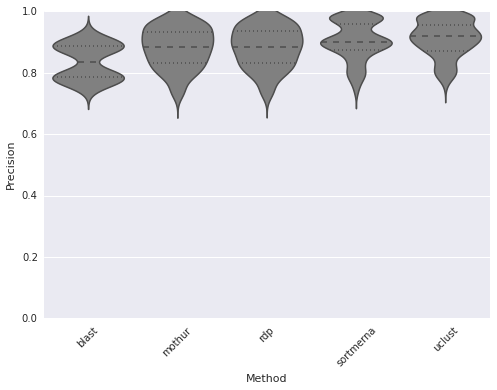

In [10]:
boxplot_from_data_frame(simulated_results, group_by="Method", metric="Precision")

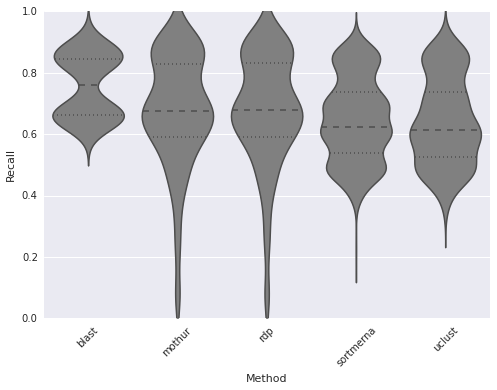

In [11]:
boxplot_from_data_frame(simulated_results, group_by="Method", metric="Recall")

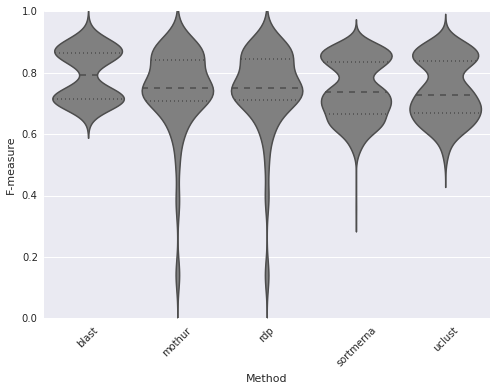

In [12]:
boxplot_from_data_frame(simulated_results, group_by="Method", metric="F-measure")

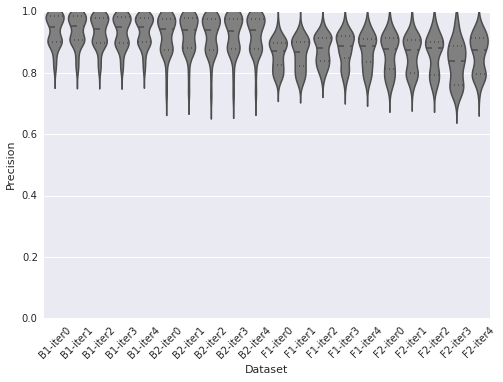

In [13]:
boxplot_from_data_frame(simulated_results, group_by="Dataset", metric="Precision")

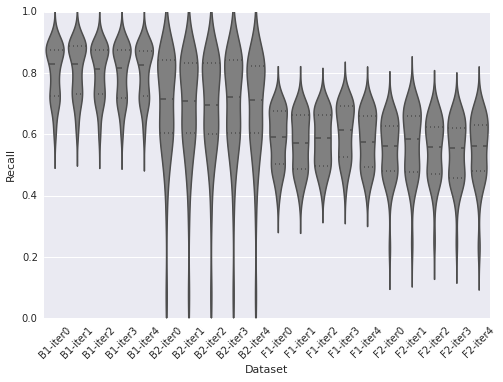

In [14]:
boxplot_from_data_frame(simulated_results, group_by="Dataset", metric="Recall")

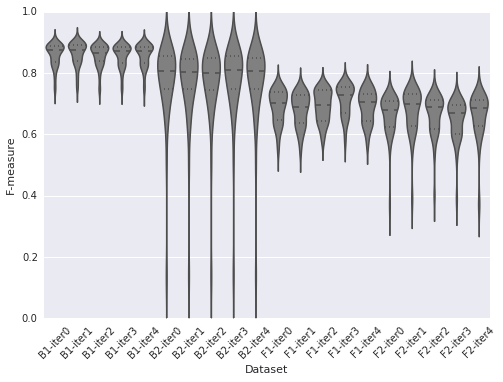

In [15]:
boxplot_from_data_frame(simulated_results, group_by="Dataset", metric="F-measure")

/usr/local/lib/python2.7/dist-packages/matplotlib/figure.py:387: UserWarning: matplotlib is currently using a non-GUI backend, so cannot show the figure
  "matplotlib is currently using a non-GUI backend, "


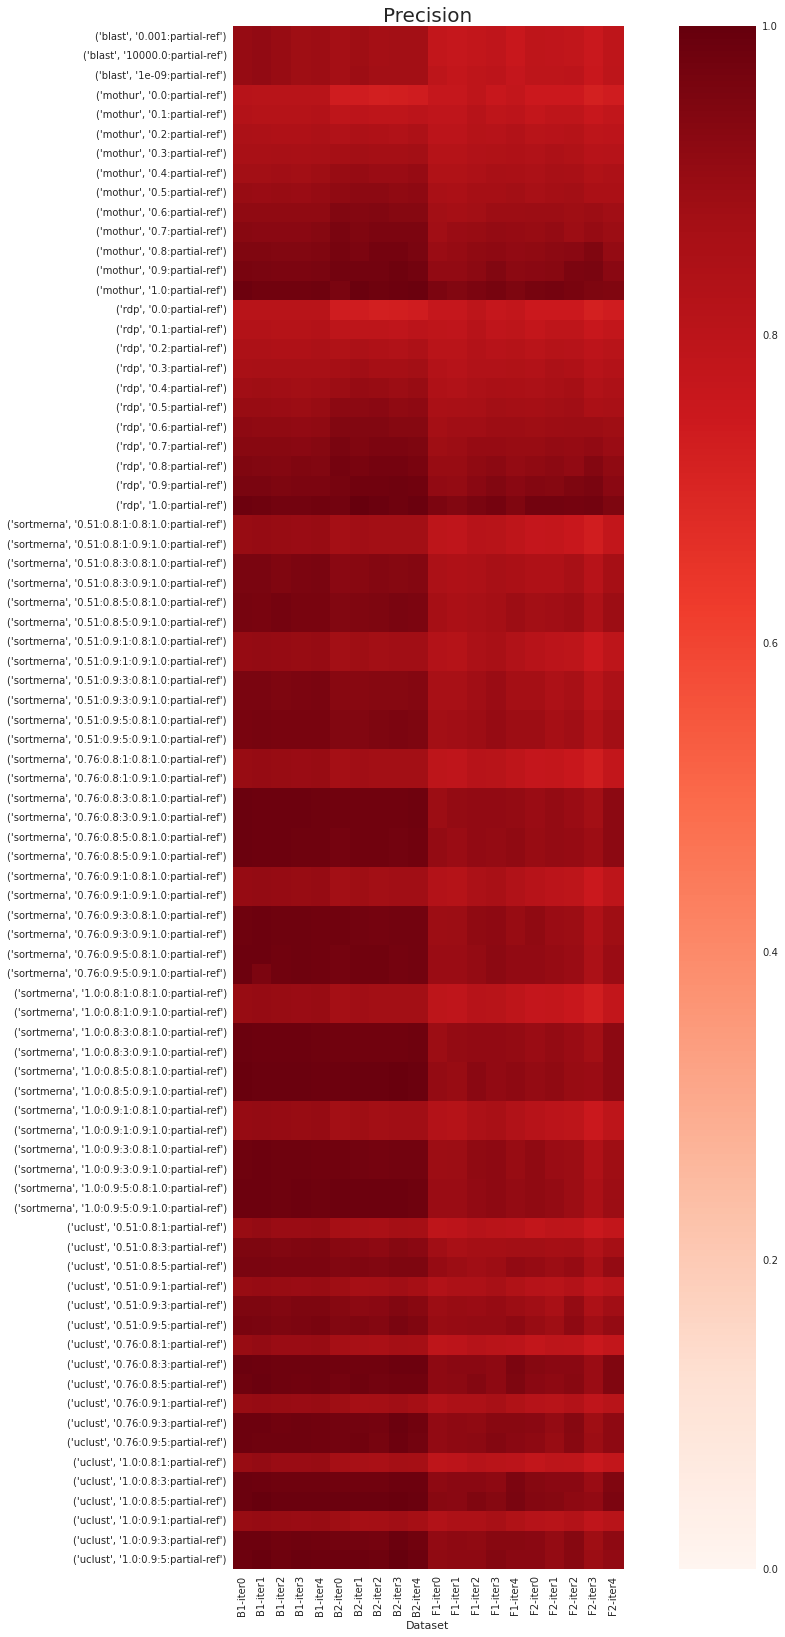

In [16]:
heatmap_from_data_frame(simulated_results, "Precision")

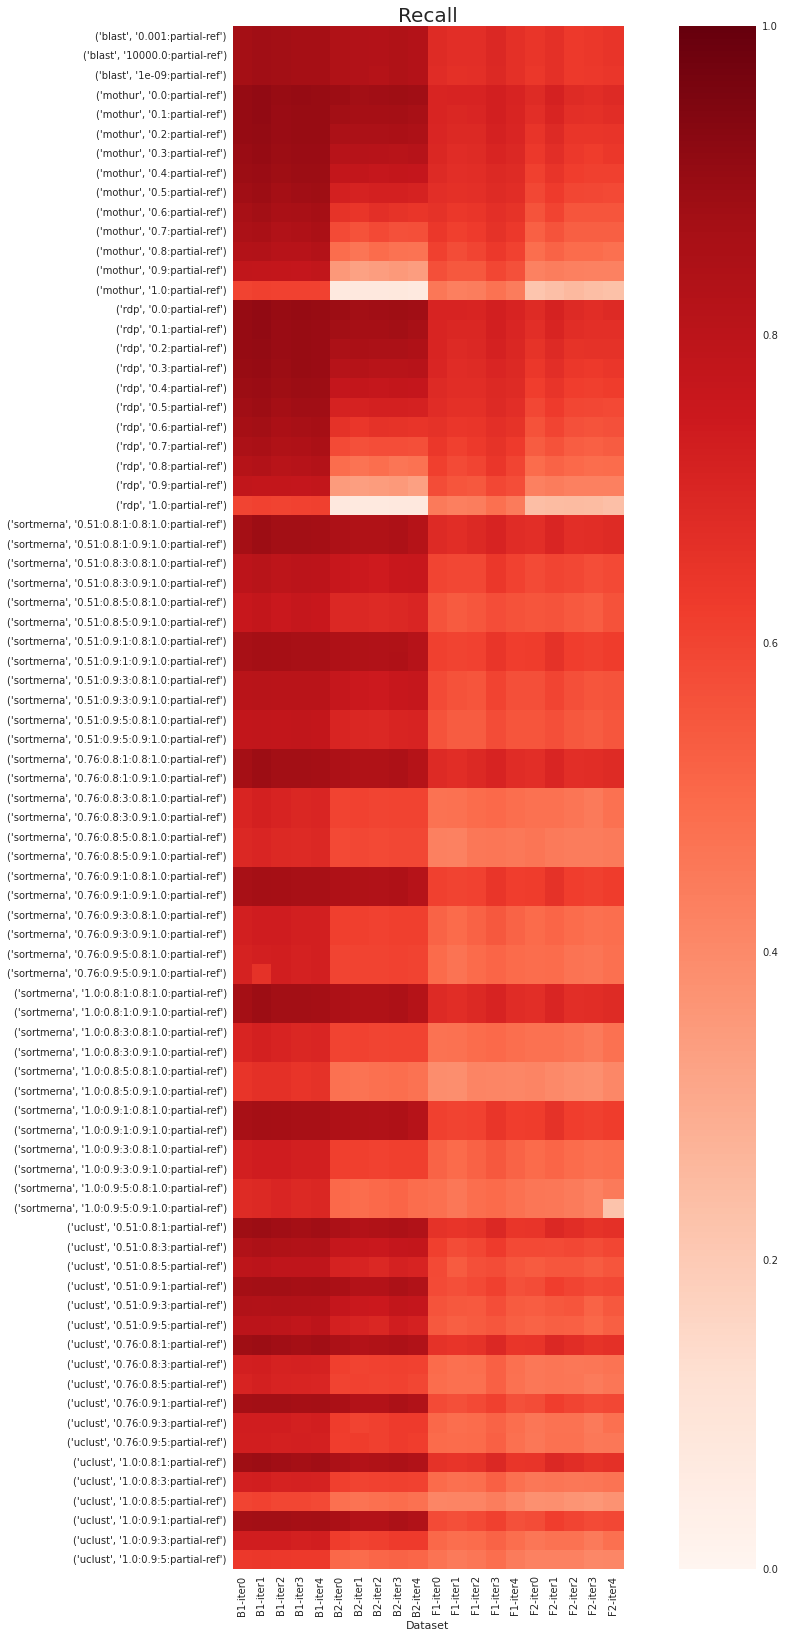

In [17]:
heatmap_from_data_frame(simulated_results, "Recall")

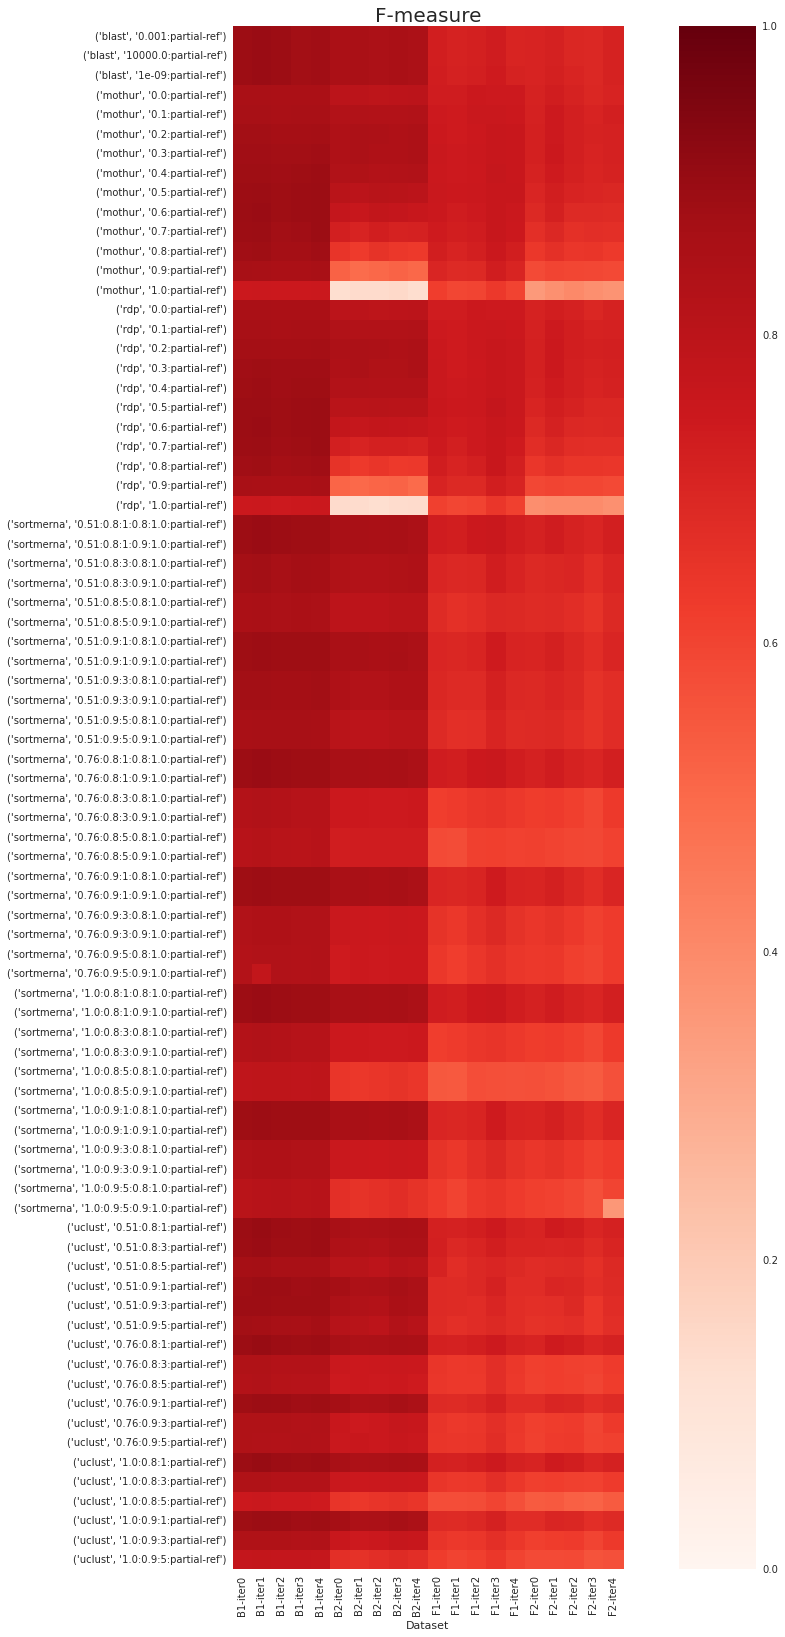

In [18]:
heatmap_from_data_frame(simulated_results, "F-measure")

In [19]:
method_by_dataset_a1(simulated_results, 'B1-iter0')

,Method,Precision,Recall,F-measure
229,rdp,0.920188,0.869455,0.894102
271,uclust,0.899678,0.886565,0.893074
2757,mothur,0.917956,0.865019,0.890701
213,blast,0.903607,0.873257,0.888173
192,sortmerna,0.901372,0.874525,0.887745


In [20]:
method_by_dataset_a1(simulated_results, 'B2-iter0')

,Method,Precision,Recall,F-measure
2154,uclust,0.882895,0.854777,0.868608
2096,sortmerna,0.873684,0.845860,0.859547
2117,blast,0.872510,0.836943,0.854356
2122,rdp,0.839421,0.849045,0.844205
3069,mothur,0.869299,0.813376,0.840408


In [21]:
method_by_dataset_a1(simulated_results, 'F1-iter0')

,Method,Precision,Recall,F-measure
1987,rdp,0.858025,0.678877,0.758010
3047,mothur,0.820660,0.698413,0.754617
1950,sortmerna,0.795745,0.684982,0.736220
1980,blast,0.793991,0.677656,0.731225
2009,uclust,0.882662,0.615385,0.725180


In [22]:
method_by_dataset_a1(simulated_results, 'F2-iter0')

,Method,Precision,Recall,F-measure
1170,rdp,0.808176,0.653113,0.722417
2900,mothur,0.808847,0.650572,0.721127
1088,sortmerna,0.770468,0.669632,0.716519
1165,blast,0.789147,0.646760,0.710894
1223,uclust,0.780488,0.650572,0.709633


## Evaluation 2: Rank-based statistics comparing the performance of the optimal parameter setting run for each method on each data set.

*Count best* column indicates how many samples a given method achieved within one mean absolute deviation of the best result (which is why they sum to more than the total number of samples).

### Within-method comparisons of parameter performance

In [23]:
metrics = ['Precision', 'Recall', 'F-measure']

In [24]:
rdp_top_params = parameter_comparisons(simulated_results, "rdp", metrics=metrics)
rdp_top_params[:15]

,F-measure,Precision,Recall
0.2:partial-ref,20,0,20
0.3:partial-ref,20,0,20
0.4:partial-ref,20,0,20
0.5:partial-ref,20,3,19
0.6:partial-ref,20,5,7
0.7:partial-ref,20,9,4
0.1:partial-ref,15,0,20
0.0:partial-ref,14,0,20
0.8:partial-ref,7,15,0
0.9:partial-ref,0,20,0


In [25]:
uclust_top_params = parameter_comparisons(simulated_results, "uclust", metrics=metrics)
uclust_top_params[:15]

,F-measure,Precision,Recall
0.51:0.8:1:partial-ref,20,0,20
0.76:0.8:1:partial-ref,20,0,20
1.0:0.8:1:partial-ref,20,0,20
0.51:0.8:3:partial-ref,20,0,13
1.0:0.9:1:partial-ref,16,0,14
0.76:0.9:1:partial-ref,16,0,14
0.51:0.9:1:partial-ref,16,0,14
0.51:0.8:5:partial-ref,16,11,0
0.51:0.9:3:partial-ref,12,4,10
0.51:0.9:5:partial-ref,10,14,0


In [26]:
sortmerna_top_params = parameter_comparisons(simulated_results, "sortmerna", metrics=metrics)
sortmerna_top_params[:15]

,F-measure,Precision,Recall
0.51:0.8:1:0.8:1.0:partial-ref,20,0,20
0.76:0.8:1:0.8:1.0:partial-ref,20,0,20
1.0:0.8:1:0.9:1.0:partial-ref,20,0,20
1.0:0.8:1:0.8:1.0:partial-ref,20,0,20
0.51:0.8:1:0.9:1.0:partial-ref,20,0,20
0.76:0.8:1:0.9:1.0:partial-ref,20,0,20
1.0:0.9:1:0.9:1.0:partial-ref,19,0,18
1.0:0.9:1:0.8:1.0:partial-ref,19,0,18
0.76:0.9:1:0.9:1.0:partial-ref,19,0,18
0.76:0.9:1:0.8:1.0:partial-ref,19,0,18


In [27]:
blast_top_params = parameter_comparisons(simulated_results, "blast", metrics=metrics)
blast_top_params[:15]

,F-measure,Precision,Recall
1e-09:partial-ref,16,20,9
0.001:partial-ref,10,6,20
10000.0:partial-ref,10,6,20


In [28]:
## OUTPUT RESULTS FOR YOUR NEW METHOD

mothur_top_params = parameter_comparisons(simulated_results, "mothur", metrics=['F-measure'])
mothur_top_params[:15]

,F-measure
0.2:partial-ref,20
0.3:partial-ref,20
0.4:partial-ref,20
0.5:partial-ref,20
0.6:partial-ref,20
0.7:partial-ref,20
0.1:partial-ref,15
0.0:partial-ref,14
0.8:partial-ref,7


### Between-method performance comparisons based on best parameter set determined above

In [29]:
sort_field = 'F-measure'
display_fields = ['Method', 'Precision', 'Recall', 'F-measure']
mp_combs = {}
## ADD YOUR METHOD TO THE LIST OF METHODS TO BE COMPARED
for e in ['rdp', 'blast', 'sortmerna', 'uclust', 'mothur']:
    mp_combs[e] = parameter_comparisons(simulated_results, e, metrics=[sort_field]).index[0]


In [30]:
method_by_dataset_iterations(simulated_results, 'B1', mp_combs.items(), sort_field, display_fields)

,Precision,Recall,F-measure
Method,,,
uclust,0.899942,0.882692,0.891231
sortmerna,0.899722,0.877123,0.888273
blast,0.898312,0.874193,0.886079
mothur,0.845547,0.902125,0.872917
rdp,0.844440,0.901366,0.871966


In [31]:
method_by_dataset_iterations(simulated_results, 'B2', mp_combs.items(), sort_field, display_fields)

,Precision,Recall,F-measure
Method,,,
sortmerna,0.877270,0.837906,0.857113
blast,0.877439,0.830902,0.853517
uclust,0.866776,0.839565,0.852936
rdp,0.842350,0.848444,0.845374
mothur,0.839728,0.848448,0.844045


In [32]:
method_by_dataset_iterations(simulated_results, 'F1', mp_combs.items(), sort_field, display_fields)

,Precision,Recall,F-measure
Method,,,
mothur,0.815231,0.699859,0.753099
rdp,0.815248,0.698901,0.752548
sortmerna,0.799920,0.687607,0.739509
uclust,0.804110,0.661324,0.725644
blast,0.786252,0.671377,0.724271


In [33]:
method_by_dataset_iterations(simulated_results, 'F2', mp_combs.items(), sort_field, display_fields)

,Precision,Recall,F-measure
Method,,,
rdp,0.811344,0.661551,0.728790
mothur,0.808283,0.656936,0.724719
uclust,0.779813,0.667389,0.719192
sortmerna,0.764011,0.679339,0.719117
blast,0.788433,0.641727,0.707473
